# Init

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax import numpy as jnp
from iaif.mouse_simple import plot_results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from sklearn import linear_model
import matplotlib as mpl
import pickle

from zipfile import ZipFile
from io import BytesIO
from urllib.request import urlopen

jax.config.update("jax_enable_x64", True)

# Setting

In [2]:
# Load targets
targets = pd.read_csv("./data/targets.csv", header=0).values[:, :2]
start_target = np.array([0.   , 0.003])

# Load data

In [39]:
# If you like to download the data used in the paper, run the following code. 
dir_path = os.path.abspath("data/simulations/iaif_data") 
if not os.path.exists(dir_path):
    download_prompt = input("Could not find reference to Paper data. Do you want to download it (~300MB)? (y/N) ")
    os.makedirs("data/simulations", exist_ok=True)
    if download_prompt.lower().startswith("y"):
        print("Will download and unzip it to 'data/simulations/'.")
        print("Downloading archive... ", end='', flush=True)
        with urlopen("https://zenodo.org/records/19115412/files/iaif_data.zip?download=1") as resp:
            zipfile = ZipFile(BytesIO(resp.read()))
            print("unzip archive... ", end='', flush=True)
            for file in zipfile.namelist():
                zipfile.extract(file, "data/simulations/")
            print("done. Simulation data is now available in 'data/simulations/iaif_data/'.")
else:
    print("Found reference to Paper data. ")


In [7]:
run_name = "VFE_EFE_sweep" # "iaif_data" # Change this to the name of your data folder in "data/simulations/" if you want to load your own data.
nplans = 1000
max_steps = 100
expected_num_repeats = 1 # 10

folder = f"./data"
input_folder = f"{folder}/simulations/{run_name}"
output_folder = f"{folder}/plots/{run_name}/plots_{nplans}"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [8]:
# Walk path and load files (can be slow)
summary_file = f"{folder}/{run_name}_{nplans}_results_summary.csv"
if os.path.exists(summary_file):
    df = pd.read_csv(summary_file)
    print("Loaded existing results summary.")
else:
    data_rows = []
    trigger_x = {}
    print("Loading data from simulations (can take 5-10 minutes)... ")
    for file in os.listdir(input_folder):
        # print(file)
        if file.endswith(".pkl"):
            if nplans is not None:
                if f"nplans_{nplans}_" not in file:
                    continue
            target = file.split("target_")[1].split("_")[0]
            repeat = file.split("rep_")[1].split(".pkl")[0]
            # Load existing dataframe
            with open(os.path.join(input_folder, file), "rb") as f:
                data_dict = pickle.load(f)
            ic_efe_threshold = data_dict['ic_efe_threshold']
            ic_timesteps = data_dict['ic_timesteps']
            ic_div_threshold = data_dict['ic_div_threshold']
            comp_time = data_dict['computation_time']
            xx = data_dict['xx']
            oo = data_dict['oo']
            timesteps_inside_target = sum(np.array([o[1] for o in oo]) > 0.9)
            ii_fired = data_dict['ii_fired']
            ii_threshold = data_dict['ii_threshold']
            reaction_time_steps = int(data_dict['reaction_time'] / data_dict['dt'])
            ii_timesteps = [i + (reaction_time_steps - 1) for i, f in enumerate(ii_fired) if f]

            data_row = {'target': target, 'repeat': repeat, 'ic_efe_threshold': ic_efe_threshold,  'ic_div_threshold': ic_div_threshold, 'num_replanning': len(ic_timesteps) if ic_timesteps is not None else len(xx)-1, 'trial_steps': len(xx), 'timesteps_inside_target': timesteps_inside_target, 'computation_time': comp_time, 'ii_timesteps': len(ii_timesteps) if ii_timesteps is not None else 100, 'ii_threshold': ii_threshold}
            # Flag as unfinished due to NaN in belief
            data_row['unfinished'] =  data_row['trial_steps'] < max_steps
            data_rows.append(data_row)

    df = pd.DataFrame(data_rows)
    df.to_csv(summary_file, index=False)


Loading data from simulations (can take 5-10 minutes)... 


240 runs | targets: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
EFE settings: ['EFE off', 'EFE thr = 1']
ii thresholds: ['off', '1e1', '1e2', '1e3', '1e4', '1e5', '1e6', '1e7', '1e8', '1e9']
repeats per config: 1-1


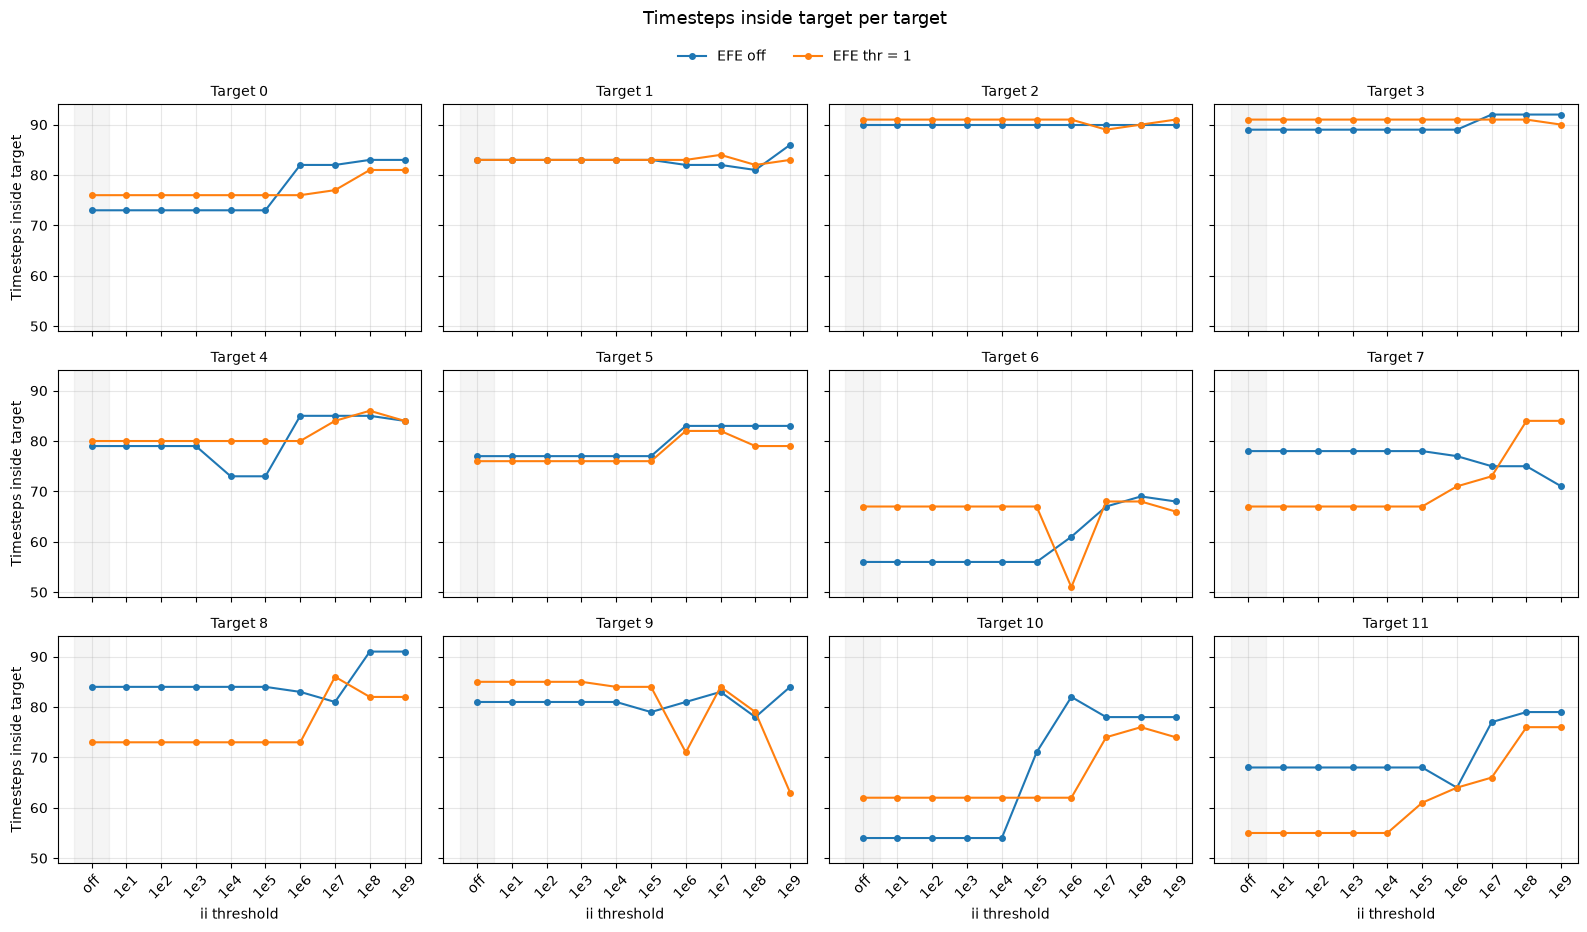

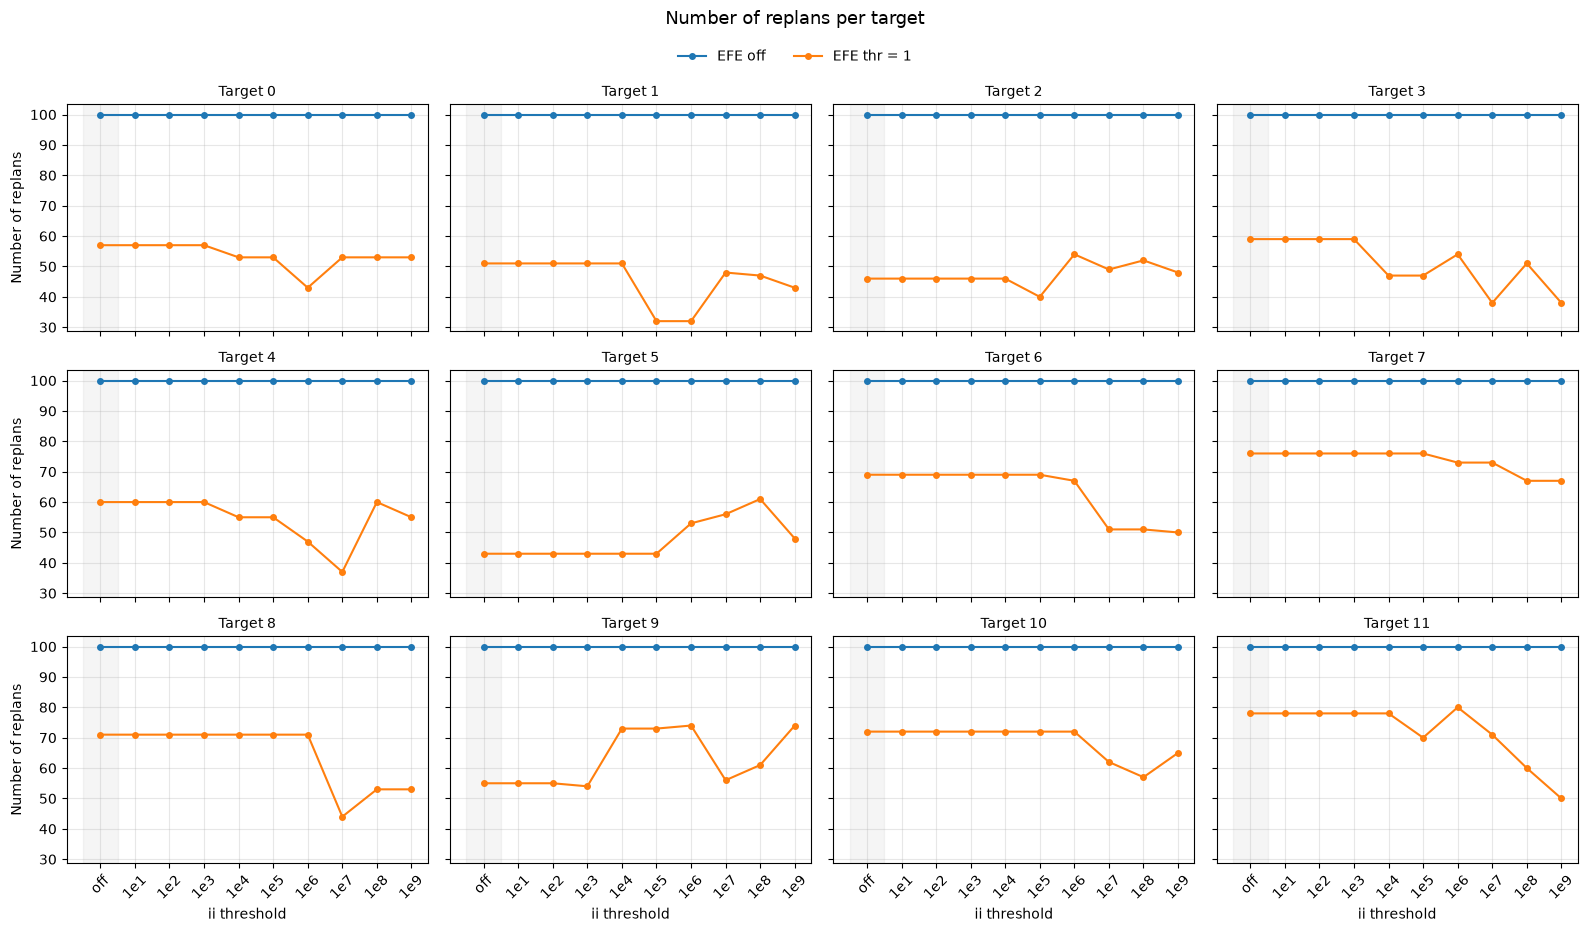

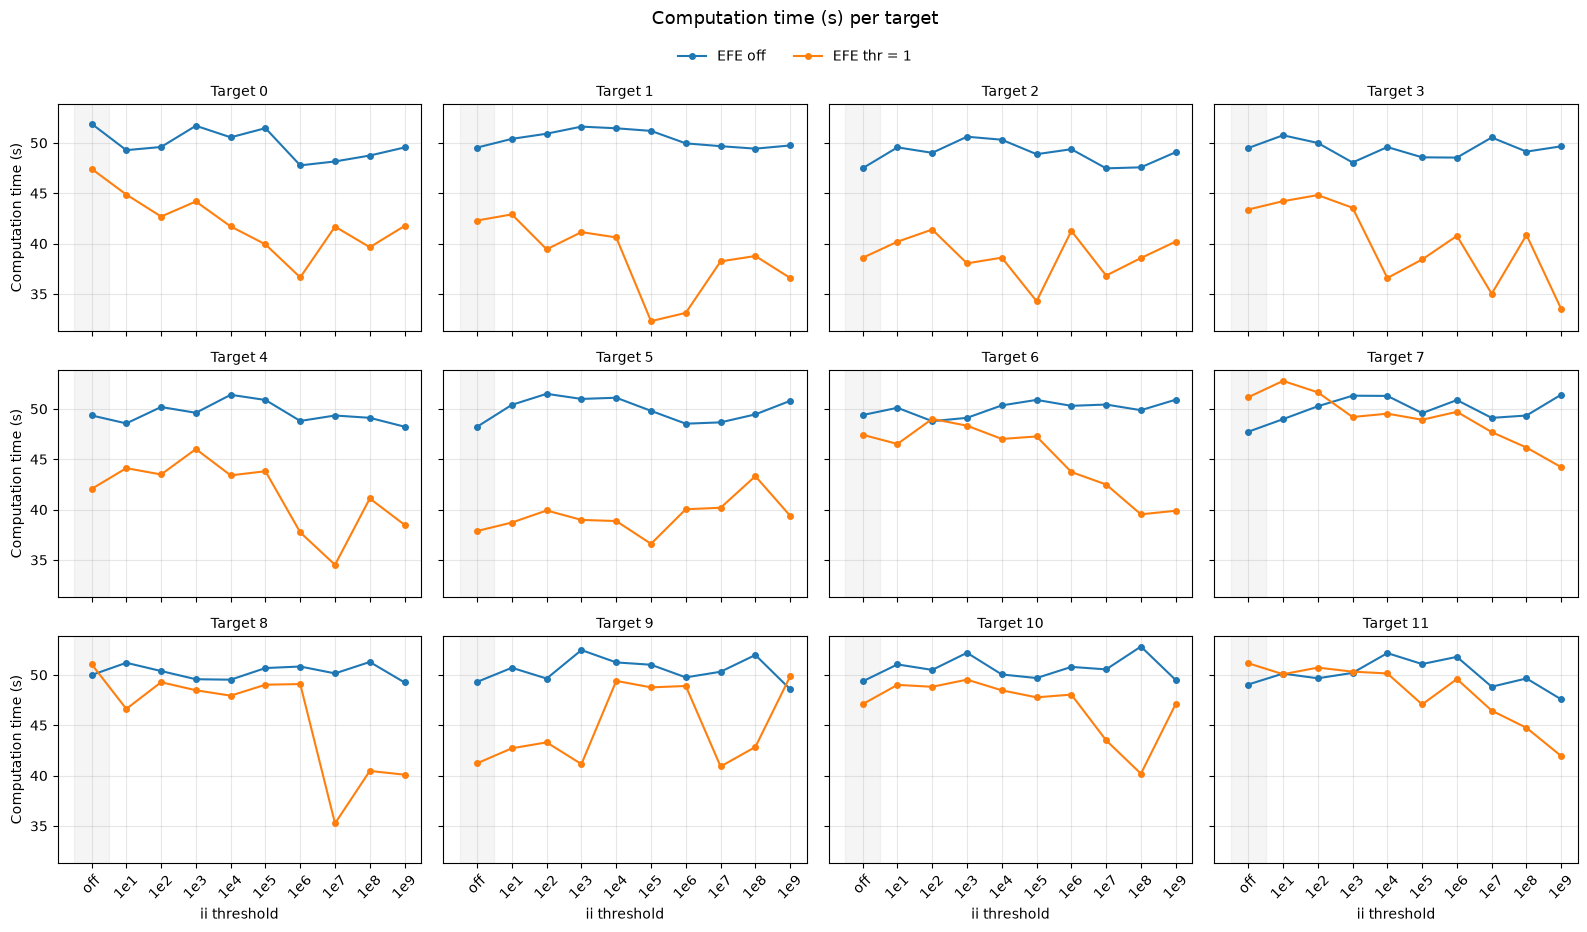

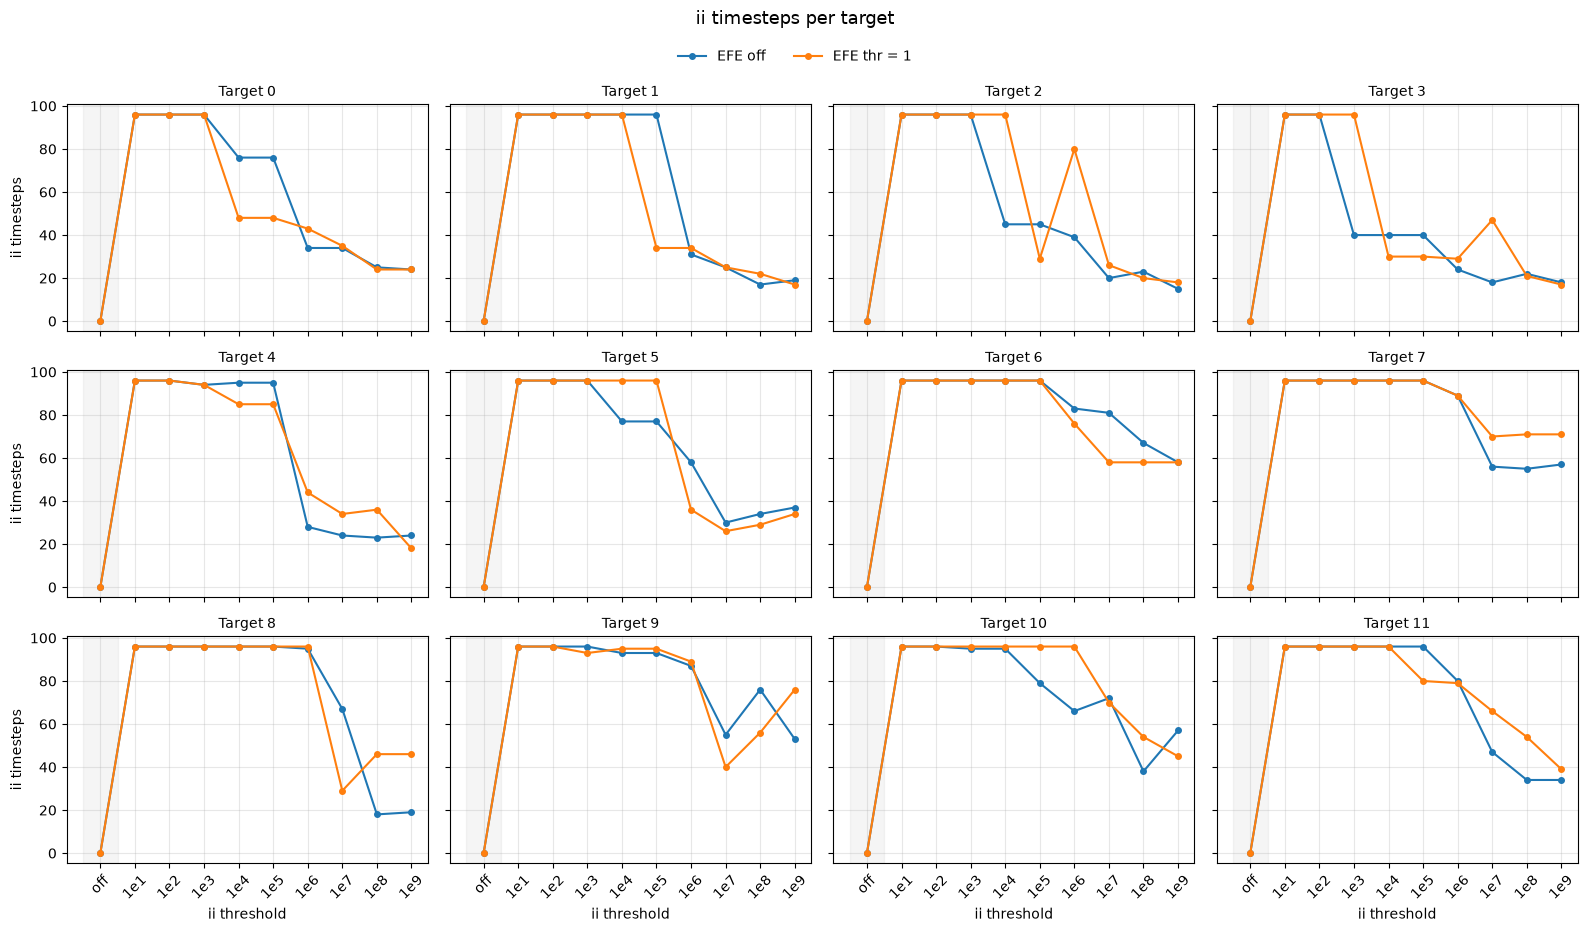

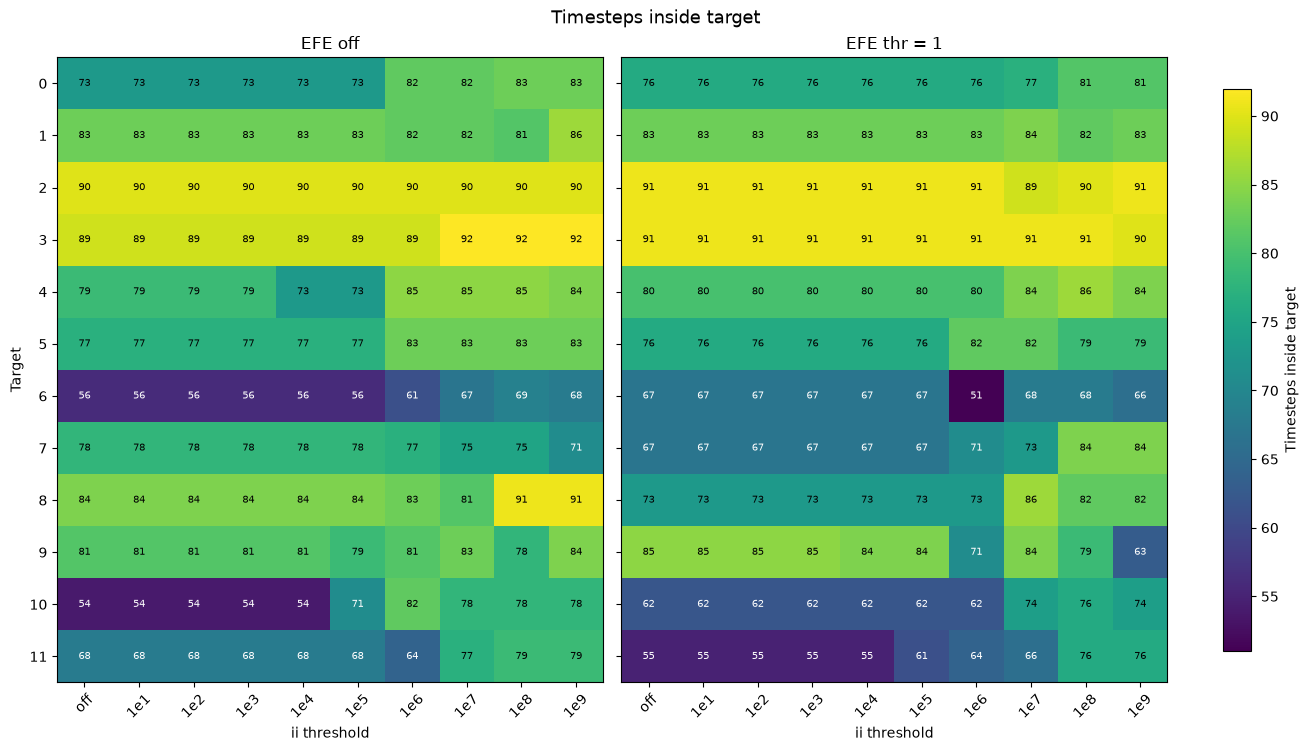

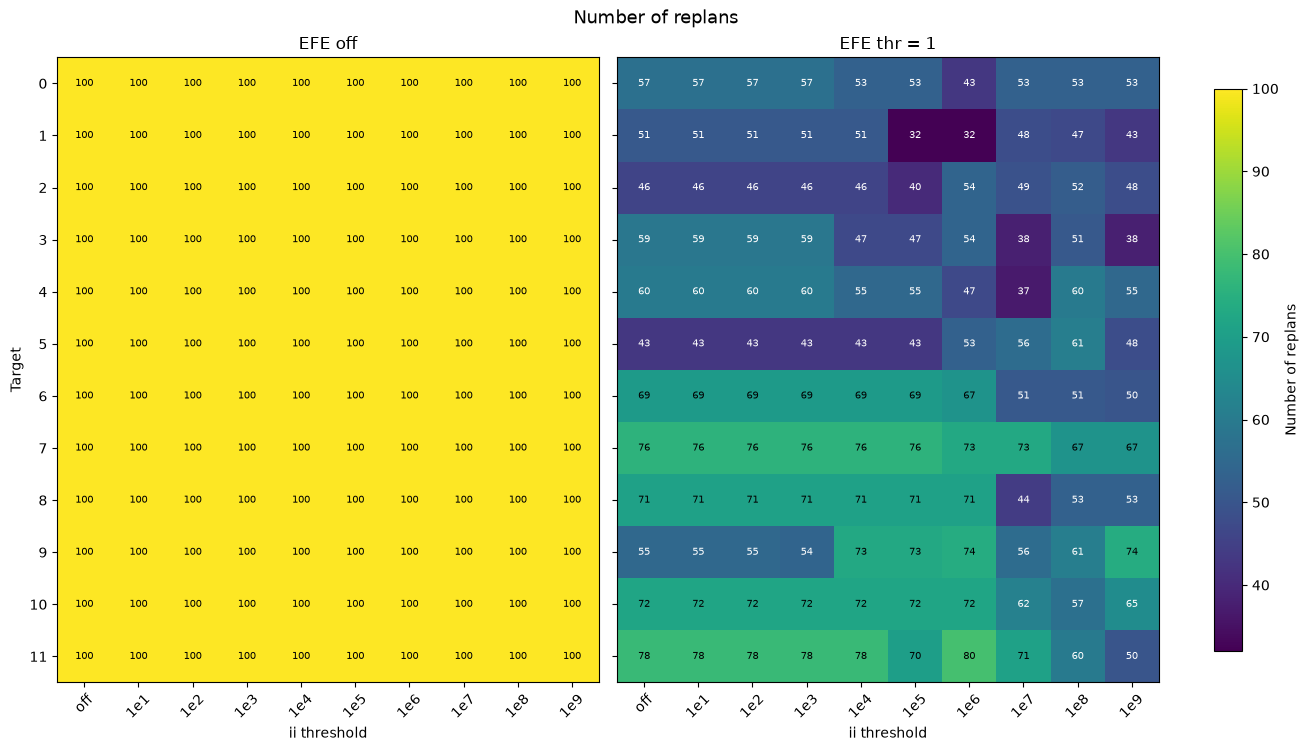

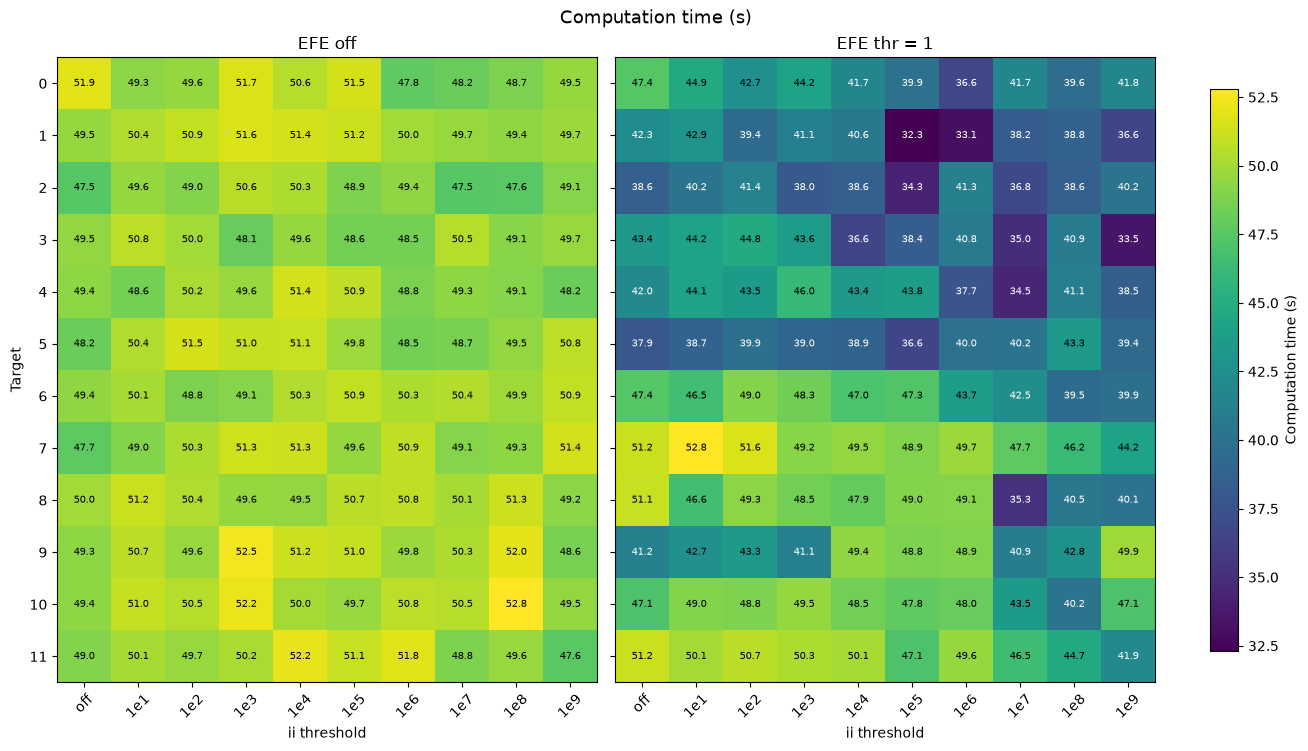

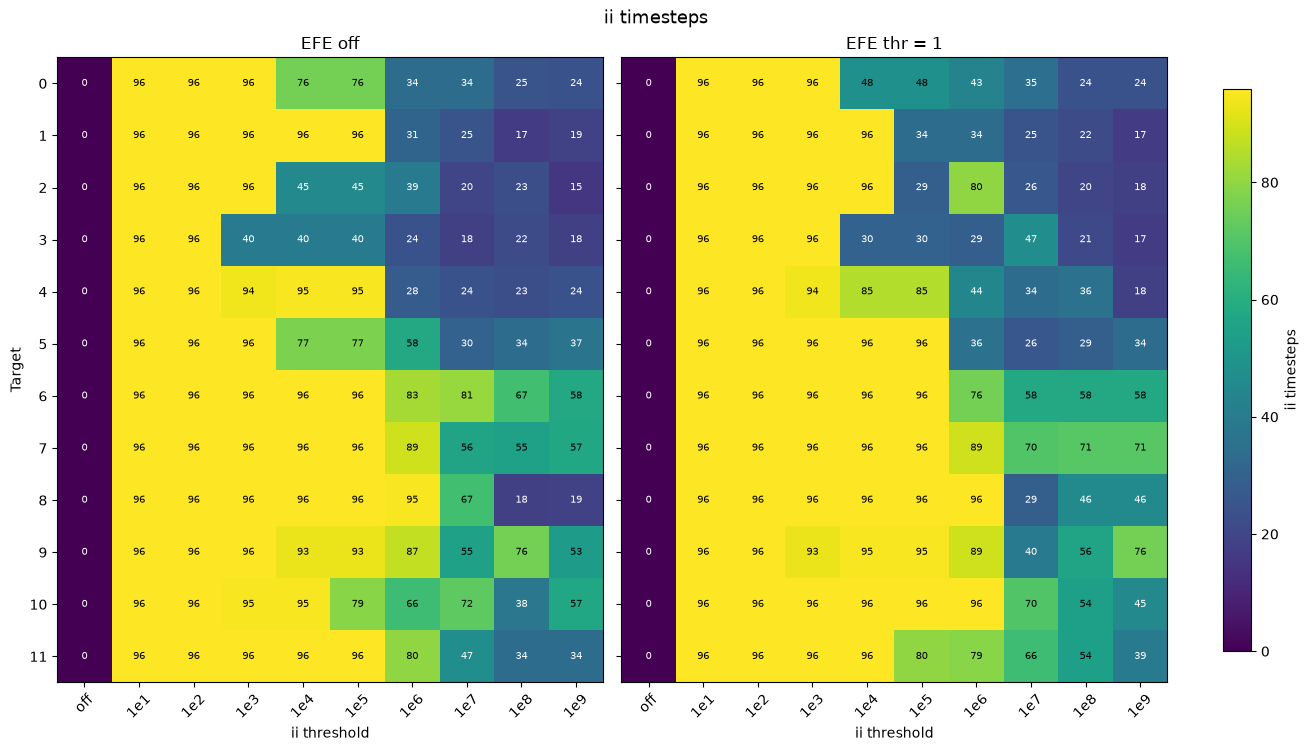

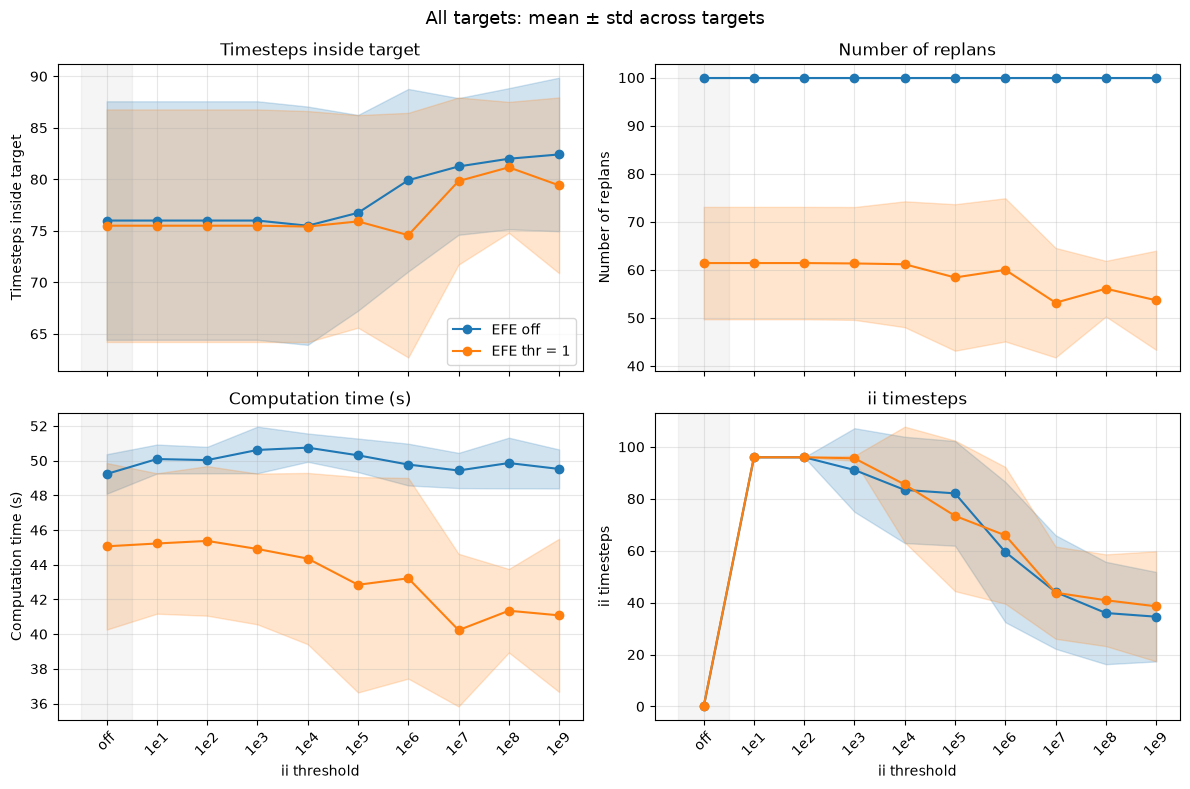

Saved plots to /home/samuel/Github/iaif/iaif/plots


In [ ]:
import argparse
import sys
from pathlib import Path
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DEFAULT_CSV = "data/VFE_EFE_sweep_1000_results_summary.csv"
 
METRICS = {
    "timesteps_inside_target": "Timesteps inside target",
    "num_replanning": "Number of replans",
    "computation_time": "Computation time (s)",
    "ii_timesteps": "ii timesteps",
}
 
EFE_OFF_LABEL = "EFE off"
II_OFF_LABEL = "off"
 
def load(csv_path):
    df = pd.read_csv(csv_path)
 
    # Human-readable labels for the two threshold dimensions
    df["efe"] = df["ic_efe_threshold"].apply(
        lambda v: EFE_OFF_LABEL if pd.isna(v) else f"EFE thr = {v:g}"
    )
    df["ii"] = df["ii_threshold"].apply(
        lambda v: II_OFF_LABEL if pd.isna(v) else f"1e{int(round(np.log10(v)))}"
    )
 
    # Ordered categories: "off" first, then increasing thresholds
    ii_vals = sorted(df["ii_threshold"].dropna().unique())
    ii_order = [II_OFF_LABEL] + [f"1e{int(round(np.log10(v)))}" for v in ii_vals]
    efe_vals = sorted(df["ic_efe_threshold"].dropna().unique())
    efe_order = [EFE_OFF_LABEL] + [f"EFE thr = {v:g}" for v in efe_vals]
 
    df["ii"] = pd.Categorical(df["ii"], categories=ii_order, ordered=True)
    df["efe"] = pd.Categorical(df["efe"], categories=efe_order, ordered=True)
 
    if df["unfinished"].any():
        print(f"Warning: {df['unfinished'].sum()} unfinished runs included")
 
    return df, ii_order, efe_order
 
def aggregate(df):
    """Mean / std / n over repeats for every (target, efe, ii) combination."""
    g = df.groupby(["target", "efe", "ii"], observed=True)[list(METRICS)]
    return g.mean(), g.std(), g.size()
 
def _in_notebook():
    return "ipykernel" in sys.modules
 
 
_SHOW = False  # set by run(); True -> also display figures inline
 
 
def _finish(fig, path):
    """Save a figure, then show it inline (notebook) or close it (script)."""
    fig.savefig(path, dpi=150, bbox_inches="tight")
    if _SHOW:
        plt.show()
    else:
        plt.close(fig)
 
def efe_colors(efe_order):
    cmap = plt.get_cmap("tab10")
    return {e: cmap(i) for i, e in enumerate(efe_order)}
 
 
def plot_per_target(mean, std, n, targets, ii_order, efe_order, out_dir):
    """One figure per metric; one subplot per target; one line per EFE setting."""
    colors = efe_colors(efe_order)
    x = np.arange(len(ii_order))
    ncols = 4
    nrows = int(np.ceil(len(targets) / ncols))
    show_err = (n > 1).any()
 
    for metric, label in METRICS.items():
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
        )
        axes = np.atleast_1d(axes).ravel()
 
        for ax, tgt in zip(axes, targets):
            for efe in efe_order:
                try:
                    m = mean.loc[(tgt, efe)][metric].reindex(ii_order)
                    s = std.loc[(tgt, efe)][metric].reindex(ii_order)
                except KeyError:
                    continue
                ax.errorbar(
                    x, m.values, yerr=s.values if show_err else None,
                    marker="o", ms=4, lw=1.5, capsize=2,
                    color=colors[efe], label=efe,
                )
            ax.set_title(f"Target {tgt}", fontsize=10)
            ax.grid(alpha=0.3)
            ax.axvspan(-0.5, 0.5, color="grey", alpha=0.08)  # shade the "ii off" column
 
        for ax in axes[len(targets):]:
            ax.set_visible(False)
        for ax in axes[-ncols:]:
            ax.set_xticks(x)
            ax.set_xticklabels(ii_order, rotation=45)
            ax.set_xlabel("ii threshold")
        for ax in axes[::ncols]:
            ax.set_ylabel(label)
 
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=len(efe_order),
                   frameon=False, bbox_to_anchor=(0.5, 1.0))
        fig.suptitle(f"{label} per target", y=1.03, fontsize=13)
        fig.tight_layout()
        _finish(fig, out_dir / f"per_target_{metric}.png")
 
def plot_heatmaps(mean, targets, ii_order, efe_order, out_dir):
    """One figure per metric; one heatmap (target x ii threshold) per EFE setting."""
    for metric, label in METRICS.items():
        grids = {}
        for efe in efe_order:
            grid = (
                mean.xs(efe, level="efe")[metric]
                .unstack("ii")
                .reindex(index=targets, columns=ii_order)
            )
            grids[efe] = grid
        vmin = min(np.nanmin(g.values) for g in grids.values())
        vmax = max(np.nanmax(g.values) for g in grids.values())
 
        fig, axes = plt.subplots(
            1, len(efe_order), figsize=(6.5 * len(efe_order), 0.45 * len(targets) + 2),
            sharey=True, constrained_layout=True,
        )
        axes = np.atleast_1d(axes)
        for ax, efe in zip(axes, efe_order):
            g = grids[efe]
            im = ax.imshow(g.values, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(ii_order)))
            ax.set_xticklabels(ii_order, rotation=45)
            ax.set_yticks(range(len(targets)))
            ax.set_yticklabels(targets)
            ax.set_xlabel("ii threshold")
            ax.set_title(efe)
            # annotate cells
            fmt = "{:.1f}" if metric == "computation_time" else "{:.0f}"
            mid = (vmin + vmax) / 2
            for i in range(g.shape[0]):
                for j in range(g.shape[1]):
                    v = g.values[i, j]
                    if np.isnan(v):
                        continue
                    ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=7,
                            color="white" if v < mid else "black")
        axes[0].set_ylabel("Target")
        fig.colorbar(im, ax=axes, label=label, shrink=0.9)
        fig.suptitle(label, fontsize=13)
        _finish(fig, out_dir / f"heatmap_{metric}.png")
 
 
def plot_summary(mean, ii_order, efe_order, out_dir):
    """All metrics vs ii threshold, mean +/- std across targets, one line per EFE setting."""
    colors = efe_colors(efe_order)
    x = np.arange(len(ii_order))
    # average over targets (each target weighted equally)
    across = mean.groupby(level=["efe", "ii"], observed=True).agg(["mean", "std"])
 
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ax, (metric, label) in zip(axes.ravel(), METRICS.items()):
        for efe in efe_order:
            sub = across.loc[efe, metric].reindex(ii_order)
            ax.plot(x, sub["mean"], marker="o", color=colors[efe], label=efe)
            ax.fill_between(x, sub["mean"] - sub["std"], sub["mean"] + sub["std"],
                            color=colors[efe], alpha=0.2)
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(alpha=0.3)
        ax.axvspan(-0.5, 0.5, color="grey", alpha=0.08)
    for ax in axes[-1]:
        ax.set_xticks(x)
        ax.set_xticklabels(ii_order, rotation=45)
        ax.set_xlabel("ii threshold")
    axes[0, 0].legend()
    fig.suptitle("All targets: mean ± std across targets", fontsize=13)
    fig.tight_layout()
    _finish(fig, out_dir / "summary_all_targets.png")
 
def run(csv=DEFAULT_CSV, out="plots", show=None):
    """Make all plots. show=None -> display inline only when running in Jupyter."""
    global _SHOW
    _SHOW = _in_notebook() if show is None else show
 
    out_dir = Path(out)
    out_dir.mkdir(parents=True, exist_ok=True)
 
    df, ii_order, efe_order = load(csv)
    mean, std, n = aggregate(df)
    targets = sorted(int(t) for t in df["target"].unique())
 
    print(f"{len(df)} runs | targets: {targets}")
    print(f"EFE settings: {efe_order}")
    print(f"ii thresholds: {ii_order}")
    print(f"repeats per config: {n.min()}-{n.max()}")
 
    plot_per_target(mean, std, n, targets, ii_order, efe_order, out_dir)
    plot_heatmaps(mean, targets, ii_order, efe_order, out_dir)
    plot_summary(mean, ii_order, efe_order, out_dir)
    print(f"Saved plots to {out_dir.resolve()}")

ap = argparse.ArgumentParser()
ap.add_argument("csv", nargs="?", default=DEFAULT_CSV)
ap.add_argument("--out", default="plots")
args, _ = ap.parse_known_args()  # ignore unknown args (e.g. Jupyter's --f=...)
run(args.csv, args.out)

In [4]:
# Make sure target is int
df['target'] = df['target'].astype(int)

# Count unfinished trials
num_unfinished = df['unfinished'].sum()
print(f"Number of unfinished trials: {num_unfinished}")

# Remove unfinished trials from dataframe
df = df[df['unfinished'] == False]

Number of unfinished trials: 0


In [5]:
# Replace nans in thresholds with -1.0
df['ic_efe_threshold'] = df['ic_efe_threshold'].fillna(-1.0)
df['ic_div_threshold'] = df['ic_div_threshold'].fillna(-1.0)

# round ic_efe_threshold and ic_div_threshold to 3 decimal places 
df['ic_efe_threshold'] = df['ic_efe_threshold'].round(3)
df['ic_div_threshold'] = df['ic_div_threshold'].round(3)


In [6]:
# Check if results are complete
PRAGMATIC_THRESHOLDS = df['ic_efe_threshold'].unique() #np.hstack([np.arange(0.0, 0.9, 0.1), np.arange(0.90, 0.99, 0.02,), np.arange(0.99, 1.011, 0.002), np.arange(1.02, 1.1, 0.02), np.arange(1.1, 2.1, 0.1)])
KL_THRESHOLDS = df['ic_div_threshold'].unique() 


TARGETS = df['target'].unique().tolist()
expected_num_thresholds = PRAGMATIC_THRESHOLDS.shape[0]
results_complete = True
missing_info = []
incomplete_targets = []
for threshold in PRAGMATIC_THRESHOLDS:
    for kl_threshold in KL_THRESHOLDS:
        for target_id in TARGETS:
            if np.isnan(threshold):
                subset = df[df['ic_efe_threshold'].isnull()]
            else:   
                subset = df[df['ic_efe_threshold'] == threshold]
            if np.isnan(kl_threshold):
                subset = subset[subset['ic_div_threshold'].isnull()]
            else:
                subset = subset[subset['ic_div_threshold'] == kl_threshold]
            subset = subset[subset['target'] == target_id]
            actual_num_repeats = subset.shape[0]
            if actual_num_repeats < expected_num_repeats:
                results_complete = False
                missing_info.append((threshold, kl_threshold, target_id, expected_num_repeats - actual_num_repeats))
                if target_id not in incomplete_targets:
                    incomplete_targets.append(target_id)

if not results_complete:
    print("Missing results:")
    for info in missing_info:
        print(f"EFE Threshold {info[0]}, KL threshold {info[1]}, target {info[2]}: missing {info[3]} runs")
    # Remove incomplete results from dataframe
    if len(missing_info) > 0:
        for (threshold, kl_threshold, target_id, missing_count) in missing_info:
            print(f"Removing incomplete threshold {threshold}, KL threshold {kl_threshold}, target {target_id} with {missing_count} missing runs")
            df = df[~((df['ic_efe_threshold'] == threshold) & (df['ic_div_threshold'] == kl_threshold))]
else:
    print("Results are complete.")

Missing results:
EFE Threshold 1.0, KL threshold -1.0, target 11: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 8: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 10: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 1: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 4: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 7: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 3: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 5: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 0: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 6: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 9: missing 5 runs
EFE Threshold 1.0, KL threshold -1.0, target 2: missing 5 runs
EFE Threshold -1.0, KL threshold 30.0, target 11: missing 5 runs
EFE Threshold -1.0, KL threshold 30.0, target 8: missing 5 runs
EFE Threshold -1.0, KL threshold 30.0, target 10: missing 5 runs
EFE Threshold -1.0, KL threshol

# Target Plot

In [7]:
TARGETS_Sorted = [int(t) for t in TARGETS]
TARGET_IDs = {t: np.round(np.log2((np.abs(targets[int(t)][0])/targets[int(t)][1])+1), 2) for t in TARGETS}
TARGETS_Sorted.sort()
IDs_sorted = np.unique(list(TARGET_IDs.values()))
IDs_sorted.sort()

# Add Index of Difficulty to each row
df['index_of_difficulty'] = [TARGET_IDs[target] for target in df['target']]

NameError: name 'targets' is not defined

In [8]:
colors_large = mpl.colormaps['cool'](np.linspace(0, 1, 6))
colors_small = mpl.colormaps['copper'](np.linspace(0, 1, 6))
colors = mpl.colormaps['plasma'](np.linspace(0.1, 0.9, len(IDs_sorted)))
ID_colors = {IDs_sorted[i]: colors[i] for i in range(len(IDs_sorted))}

target_colors = {target_nr: ID_colors[TARGET_IDs[target_nr]] for target_nr in TARGETS_Sorted}

# Plot targets for verification
fig, ax = plt.subplots(figsize=(1.618*4,4))
for i, target_nr in enumerate(TARGETS_Sorted):
    target = targets[int(target_nr)]
    rect = plt.Rectangle((0.5 * (i//6), (target[0]-target[1])*1000+900), 0.5, target[1]*2*1000, linewidth=1, fill=True, facecolor=target_colors[target_nr], edgecolor='black', alpha=1)
    ax.add_patch(rect)
    ax.text(0.25 + (i//6) *0.5, (target[0]-0.15)*1000+900, f'Target {target_nr}', ha='center', color=target_colors[target_nr])

ax.hlines(900, xmin=0, xmax=1, colors='gray', linestyles='dashed')
ax.text(0.2 , 900-70, 'Start', ha='right', color='gray')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1800)
ax.set_xticks([])
ax.set_ylabel("Cursor Position [px]")

# # Create new legend for target IDs and colors
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    

target_legend_elements = [Line2D([0], [0], marker='o', linestyle='None', color=ID_colors[id_single],
                                 label=f'{id_single:.2f}', markersize=5) for id_single in IDs_sorted]
target_legend = ax.legend(handles=target_legend_elements, title='Index of Difficulty')   
ax.add_artist(target_legend)

ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_Target_Locations.pdf", dpi=300)

NameError: name 'IDs_sorted' is not defined

# Settings for Plots

In [9]:
# Fix hue order
df = df.sort_values(by=['ic_efe_threshold', 'ic_div_threshold'], ascending=[False, False])
hue_order = sorted(df["ic_div_threshold"].dropna().unique(), reverse=False)
hue_order.remove(-1.)
hue_order.append(-1.)
df["ic_div_threshold"] = pd.Categorical(df["ic_div_threshold"], categories=hue_order, ordered=True)
palette = sns.color_palette("YlOrBr", len(hue_order))

In [10]:
# Separate Data
df_baseline = df[(df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == -1.)]
df_wo_baseline = df[~((df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == -1.))]
df_limited = df_wo_baseline[df_wo_baseline['ic_efe_threshold'].isin([-1.0, 1.0])]
df_only_div = df_limited[df_limited['ic_efe_threshold'] == -1.0]
df_only_div = df_only_div[df_only_div['ic_div_threshold'] != -1.0]
df_efe_only = df[(df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == 1.)]
df_combined = df_limited[df_limited['ic_efe_threshold'] != -1.0]
df_combined = df_combined[df_combined['ic_div_threshold'] != -1.0]


In [11]:
# Print all mean values
for ic_efe_threshold in df['ic_efe_threshold'].unique():
    for ic_div_threshold in df['ic_div_threshold'].unique():
        subset = df[(df['ic_efe_threshold'] == ic_efe_threshold) & (df['ic_div_threshold'] == ic_div_threshold)]
        mean_replanning = subset['num_replanning'].mean()
        mean_comp_time = subset['computation_time'].mean()
        mean_success_rate = subset['timesteps_inside_target'].mean()
        print(f"Mean values for EFE Threshold {ic_efe_threshold}, DIV Threshold {ic_div_threshold}:")
        print(f"  Mean Number of Replannings: {mean_replanning:.3f}")
        print(f"  Mean Computation Time: {mean_comp_time:.3f}s")
        print(f"  Mean Time on Target [%] (Timesteps Inside Target): {mean_success_rate:.3f}")

for ii_threshold in df['ii_threshold'].unique():
    subset = df[df['ii_threshold'] == ii_threshold]
    print(f"Mean values for II Threshold {ii_threshold}:")
    print(f"  Mean Number of Inference Updates: {subset['num_inference'].mean():.3f}")
    print(f"  Mean Number of Replannings: {subset['num_replanning'].mean():.3f}")
    print(f"  Mean Computation Time: {subset['computation_time'].mean():.3f}s")
    print(f"  Mean Time on Target [%] (Timesteps Inside Target): {subset['timesteps_inside_target'].mean():.3f}")

Mean values for EFE Threshold 1.0, DIV Threshold 30.0:
  Mean Number of Replannings: 74.950
  Mean Computation Time: 45.498s
  Mean Time on Target [%] (Timesteps Inside Target): 76.767
Mean values for EFE Threshold 1.0, DIV Threshold -1.0:
  Mean Number of Replannings: nan
  Mean Computation Time: nans
  Mean Time on Target [%] (Timesteps Inside Target): nan
Mean values for EFE Threshold -1.0, DIV Threshold 30.0:
  Mean Number of Replannings: nan
  Mean Computation Time: nans
  Mean Time on Target [%] (Timesteps Inside Target): nan
Mean values for EFE Threshold -1.0, DIV Threshold -1.0:
  Mean Number of Replannings: 100.000
  Mean Computation Time: 51.451s
  Mean Time on Target [%] (Timesteps Inside Target): 78.333
Mean values for II Threshold 1000000.0:


KeyError: 'num_inference'

# Trigger Events

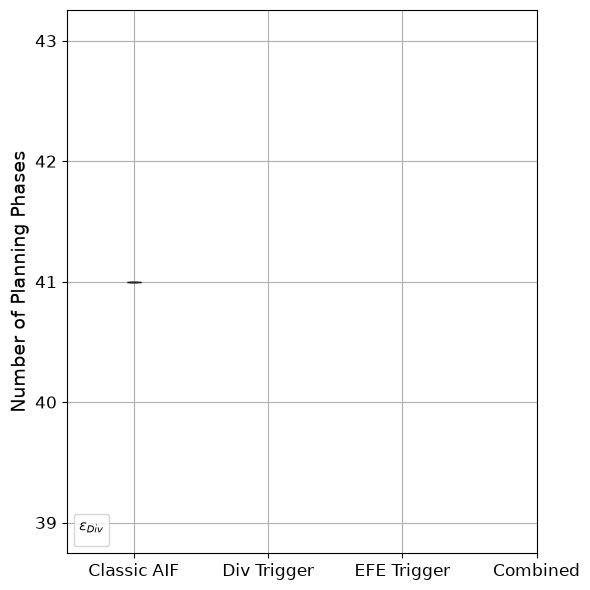

In [13]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(data=df_baseline, x=0.0, y='num_replanning',ax=ax, color='blue',  width=1/10) 
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='num_replanning', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False) 
sns.boxplot(data=df_efe_only, x=2.0, y='num_replanning',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='num_replanning', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette) 

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

# Change x ticks to Without EFE Trigger and With EFE Trigger
ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Number of Planning Phases")

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_vs_Num_IC_Triggers.pdf")


# Computation Time

AttributeError: 'NoneType' object has no attribute 'set_title'

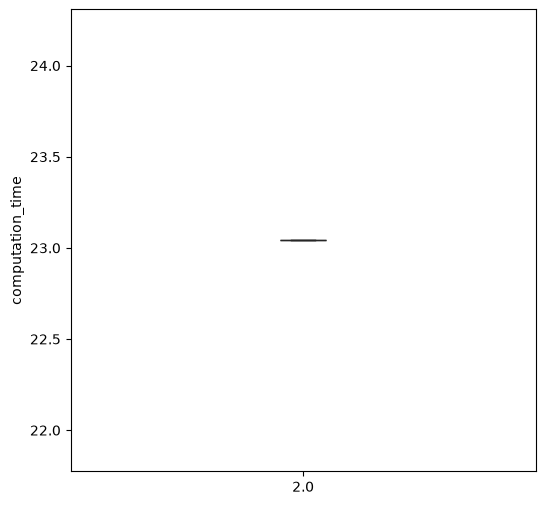

In [14]:
fig, ax = plt.subplots(figsize=(6,6))


sns.boxplot(data=df_baseline, x=0.0, y='computation_time',ax=ax, color='blue',  width=1/10)
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='computation_time', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False) 
sns.boxplot(data=df_efe_only, x=2.0, y='computation_time',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='computation_time', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette)

boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)


# Change x ticks
ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Computation Time [s]")

plt.grid(True) 
plt.tight_layout()

plt.savefig(f"{output_folder}/ic_efe_threshold_vs_Computation_Time.pdf", dpi=300)

# Successful Trials

AttributeError: 'NoneType' object has no attribute 'set_title'

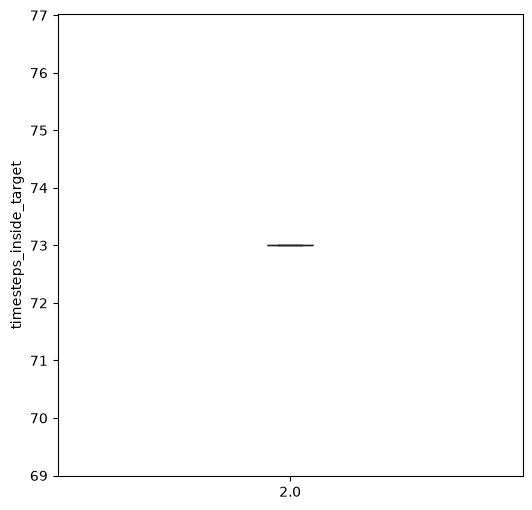

In [15]:
# Plot Time on Target [%]
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(data=df_baseline, x=0.0, y='timesteps_inside_target',ax=ax, color='blue',  width=1/10)
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='timesteps_inside_target', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False)
sns.boxplot(data=df_efe_only, x=2.0, y='timesteps_inside_target',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='timesteps_inside_target', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette) 

# Change legend for kl threshold -1.0 to "No"
boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Percentage Time on Target [%]")

ax.set_ylim(40, 100)

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Success_Rate.pdf")

## Performance vs. Success

In [ ]:
# Plot Time on Target [%] against computation time color by ic_efe_threshold
fig, ax = plt.subplots(figsize=(12,6))

df.sort_values(by=['target', 'ic_efe_threshold', 'ic_div_threshold'], ascending=[True, False, False], inplace=True)

df_baseline = df[(df['ic_efe_threshold']==-1.0)&(df['ic_div_threshold']==-1.0)]
df_aif = df[(df['ic_efe_threshold']==1.0)&(df['ic_div_threshold']==-1.0)]
df_div = df[(df['ic_efe_threshold']==-1.0)&(df['ic_div_threshold']==30.0)]
targets_in_legend = df_baseline['target'].unique()

markers = [(3,1,0),(4,1,0),(5,1,0),(6,1,0),(7,1,0),(8,1,0)]
markersize=8
sizes = [120,100,80,60,40,20]

scatter = sns.scatterplot(data=df_baseline, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',  marker='s', color='blue', legend=False, sizes=sizes)
scatter = sns.scatterplot(data=df_aif, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',   marker='o', color='green', legend=False, sizes=sizes)
scatter = sns.scatterplot(data=df_div, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',  marker='^', color='orange', legend=True, sizes=sizes)

# Add regression lines for each condition
x = df_baseline['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_baseline['computation_time'].to_numpy().reshape(-1, 1)
regr_baseline = linear_model.LinearRegression()
regr_baseline.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_baseline.predict(x).reshape(-1,)}, x='x',y='y', color='black', linestyle='-', ax=ax,alpha=0.7)

x = df_aif['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_aif['computation_time'].to_numpy().reshape(-1, 1)
regr_aif = linear_model.LinearRegression()
regr_aif.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_aif.predict(x).reshape(-1,)}, x='x',y='y',  color='black', linestyle='--',ax=ax, alpha=0.7)

x = df_div['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_div['computation_time'].to_numpy().reshape(-1, 1)
regr_div = linear_model.LinearRegression()
regr_div.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_div.predict(x).reshape(-1,)}, x='x',y='y', linestyle=':', color='black', linewidth=1, ax=ax, alpha=0.7)

legend_elements = [
    Line2D([0], [0], linestyle='-', color='blue', marker='s', fillstyle='none',
           label='Classic AIF', markersize=markersize),
    Line2D([0], [0], linestyle='--', color='green', marker='o', fillstyle='none',
           label='IAIF - EFE Trigger only', markersize=markersize),
    Line2D([0], [0], linestyle=':', color='orange', marker='^', fillstyle='none',
           label='IAIF - Div Trigger only ($\epsilon_{Div}=30.0$)', markersize=markersize)
]
condition_legend = ax.legend(handles=legend_elements, title='Condition', loc='upper right')
ax.add_artist(condition_legend)

# Create new legend for target IDs 
target_legend_elements = [Line2D([0], [0], marker='o', linestyle='None', color="black",
                                 label=f'{id_single:.2f}', markersize=sizes[i]/10) for i,id_single in enumerate(IDs_sorted)]
target_legend = ax.legend(handles=target_legend_elements, title='Index of Difficulty', loc='upper left')   
ax.add_artist(target_legend)

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

ax.set_ylabel("Computation Time [s]")
ax.set_xlabel("Percentage Time on Target [%]")

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_Time_Steps_Inside_Target_vs_Computation_Time_Scatter_limited.pdf")  

# Single Trajectory

## IAIF

None
Rows: [['pos', 'pos']]


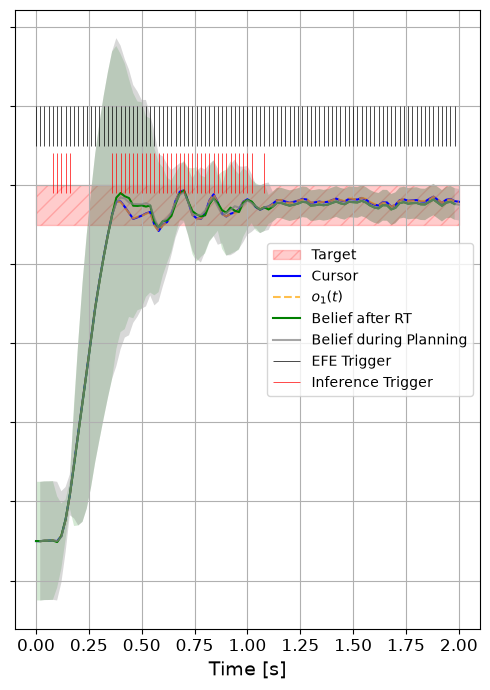

In [20]:
ic_efe_threshold = None
ic_div_threshold = None
ii_threshold = 1e6
target_id = 0
repeat = 0

# Load example data for plotting
file = f"{input_folder}/target_{target_id}_{f'nplans_{nplans}_pred_{ic_div_threshold}_' if nplans is not None else ''}prag_{ic_efe_threshold}_inf_{ii_threshold}_rep_{repeat}.pkl"
with open(file, "rb") as f:
    data_dict = pickle.load(f)
dt = data_dict['dt']
xx = data_dict['xx']
oo = data_dict['oo']
bb = data_dict['bb']
aa = data_dict['aa']
aa_applied = data_dict['aa_applied']
lll = data_dict['lll']
nefe_plan = data_dict['nefe_plan']
pragmatic_plan = data_dict['pragmatic_plan']
info_gain_plan = data_dict['info_gain_plan']
buttons = data_dict['buttons']
ic_timesteps = data_dict['ic_timesteps']
bb_predicted = data_dict['bb_predicted']
bb_after_rt = data_dict['bb_after_rt']
params = data_dict['params']
ic_div_threshold = data_dict['ic_div_threshold']
print(ic_div_threshold)
ic_efe_threshold = data_dict['ic_efe_threshold']

numsteps = len(xx)-1

rows = []
rows.append(['pos', 'pos'])

figsize_x = 5
fig, ax = plt.subplot_mosaic(rows, figsize=(figsize_x,7*len(rows)))
plot_axes = ['pos']


xx_new = []
for x in xx:
    x0 = (x[0]*1000 + 900) # Convert to pixels
    x1 = x[1]*1000
    x2 = x[2]*1000 + 900 # Convert to pixels
    x3 = x[3]*1000 # Convert to pixels
    x_new = jnp.array([x0, x1, x2, x3])
    xx_new.append(x_new)

oo_new = [o.at[0].set(o[0]*1000 + 900) for o in oo] # Convert to pixels

bb_new = []
for b in bb:
    b0 = b[0].at[0].set(b[0][0]*1000 + 900) # Convert to pixels
    b0 = b0.at[2].set(b[0][2]*1000 + 900) # Convert to pixels
    b0 = b0.at[3].set(b[0][1]*1000) # Convert to pixels
    b1 = b[1].at[0,0].set(b[1][0,0]*1000**2) # Convert to pixels
    bb_new.append((b0, b1))

buttons[1] = [buttons[1][0]*1000+900, buttons[1][1]*1000]


fig, ax, t = plot_results(dt, xx_new, oo_new, bb_new, aa, aa_applied, lll, nefe_plan, pragmatic_plan, info_gain_plan, hide_belief=True, belief_button=False, fig=fig, ax=ax, plot_axes=plot_axes)
std_mult = 3

# Belief after reaction time
mean = [b[0][0]*1000 + 900 for b in bb_after_rt]
var = [b[1][0, 0]*1000**2 for b in bb_after_rt]
ax['pos'].plot(t[:-1], mean, label=['Belief after RT'], color='green')
ribbons = np.array([[mean[i] - std_mult * np.sqrt(var[i]), mean[i] + std_mult * np.sqrt(var[i])] for i in range(len(mean))])
ax['pos'].fill_between(t[:-1], ribbons[:, 0], ribbons[:, 1], facecolor="green", alpha=1 / 6)

# # Plot predicted belief trajectory
predicted_means = [bb_predicted[i][0][0]*1000+900 for i in bb_predicted if i <= len(xx)-1]
ax['pos'].plot(t[1:], predicted_means, color='grey', label='Belief during Planning', alpha=0.7)
predicted_covs = [bb_predicted[i][1][0,0]*1000**2 for i in bb_predicted if i <= numsteps]
ribbons = np.array([[predicted_means[i] - std_mult * np.sqrt(predicted_covs[i]), predicted_means[i] + std_mult * np.sqrt(predicted_covs[i])] for i in range(len(predicted_means))])
ax['pos'].fill_between(t[1:], ribbons[:, 0], ribbons[:, 1], facecolor="grey", alpha=0.3)

# IC timesteps
if len(ic_timesteps)>0:
    ax['pos'].vlines(np.array(ic_timesteps)*dt, ymin=1900, ymax=2000, color='black', label='EFE Trigger', alpha=1.0, linewidth=0.5)

# II timesteps
reaction_time_steps = int(round(data_dict['reaction_time'] / dt))
ii_fired = data_dict.get('ii_fired', [])
ii_timesteps = [i + max(reaction_time_steps - 1, 0) for i, f in enumerate(ii_fired) if f]
if len(ii_timesteps) > 0:
    ax['pos'].vlines(np.array(ii_timesteps)*dt, ymin=1780, ymax=1880, color='red', label='Inference Trigger', alpha=1.0, linewidth=0.5)

ic_efe_threshold = data_dict['ic_efe_threshold']
ax['pos'].legend(loc='center right')

# get ylims
ylims = ax['pos'].get_ylim()

ax['pos'].set_yticklabels([])
ax['pos'].set_ylabel('')


# Increase Label and ticks font size
ax['pos'].xaxis.label.set_size(14)
ax['pos'].yaxis.label.set_size(14)
ax['pos'].tick_params(axis='both', which='major', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Single_Trial_prag_{ic_efe_threshold}_kl_{ic_div_threshold}_target_{target_id}_rep_{repeat}.pdf")

## AIF Baseline

In [16]:
# Standard AIF baseline
ic_efe_threshold = None
ic_div_threshold = None

# Load example data for plotting
file = f"{input_folder}/target_{target_id}_{f'nplans_{nplans}_pred_{ic_div_threshold}_' if nplans is not None else ''}prag_{ic_efe_threshold}_rep_{repeat}.pkl"
with open(file, "rb") as f:
    data_dict = pickle.load(f)
dt = data_dict['dt']
xx = data_dict['xx']
oo = data_dict['oo']
bb = data_dict['bb']
aa = data_dict['aa']
aa_applied = data_dict['aa_applied']
lll = data_dict['lll']
nefe_plan = data_dict['nefe_plan']
pragmatic_plan = data_dict['pragmatic_plan']
info_gain_plan = data_dict['info_gain_plan']
buttons = data_dict['buttons']
ic_timesteps = data_dict['ic_timesteps']
bb_predicted = data_dict['bb_predicted']
bb_after_rt = data_dict['bb_after_rt']
params = data_dict['params']
ic_div_threshold = data_dict['ic_div_threshold']
ic_efe_threshold = data_dict['ic_efe_threshold']

numsteps = len(xx)-1

rows = []
rows.append(['pos', 'pos'])

fig, ax = plt.subplot_mosaic(rows, figsize=(figsize_x,7*len(rows)))
plot_axes = ['pos']

xx_new = []
for x in xx:
    x0 = (x[0]*1000 + 900) # Convert to pixels
    x1 = x[1]*1000
    x2 = x[2]*1000 + 900# Convert to pixels
    x3 = x[3]*1000 # Convert to pixels
    x_new = jnp.array([x0, x1, x2, x3])
    xx_new.append(x_new)

oo_new = [o.at[0].set(o[0]*1000 + 900) for o in oo] # Convert to pixels

bb_new = []
for b in bb:
    b0 = b[0].at[0].set(b[0][0]*1000 + 900) # Convert to pixels
    b0 = b0.at[2].set(b[0][2]*1000 + 900) # Convert to pixels
    b0 = b0.at[3].set(b[0][1]*1000) # Convert to pixels
    b1 = b[1].at[0,0].set(b[1][0,0]*1000**2) # Convert to pixels
    bb_new.append((b0, b1))


buttons[1] = [buttons[1][0]*1000+900, buttons[1][1]*1000]

fig, ax, t = plot_results(dt, xx_new, oo_new, bb_new, aa, aa_applied, lll, nefe_plan, pragmatic_plan, info_gain_plan,  hide_belief=True, fig=fig, ax=ax, plot_axes=plot_axes)
std_mult = 3

# Belief after reaction time
mean = [b[0][0]*1000 + 900 for b in bb_after_rt]
var = [b[1][0, 0]*1000**2 for b in bb_after_rt]
ax['pos'].plot(t[:-1], mean, label=['belief after RT'], color='green')
ribbons = np.array([[mean[i] - std_mult * np.sqrt(var[i]), mean[i] + std_mult * np.sqrt(var[i])] for i in range(len(mean))])
ax['pos'].fill_between(t[:-1], ribbons[:, 0], ribbons[:, 1], facecolor="green", alpha=1 / 6)

# # Plot predicted belief trajectory
predicted_means = [bb_predicted[i][0][0]*1000+900 for i in bb_predicted if i <= len(xx)-1]
ax['pos'].plot(t[1:], predicted_means, color='grey', label='Belief during Planning', alpha=0.7)
predicted_covs = [bb_predicted[i][1][0,0]*1000**2 for i in bb_predicted if i <= numsteps]
ribbons = np.array([[predicted_means[i] - std_mult * np.sqrt(predicted_covs[i]), predicted_means[i] + std_mult * np.sqrt(predicted_covs[i])] for i in range(len(predicted_means))])
ax['pos'].fill_between(t[1:], ribbons[:, 0], ribbons[:, 1], facecolor="grey", alpha=0.3)


# IC timesteps (Baseline - trigger every step)
baseline_trigger = [i for i in range(numsteps)]
ax['pos'].vlines(np.array([baseline_trigger])*dt,  ymin=1900, ymax=2000, color='black', alpha=1.0, linewidth=0.5)

ax['pos'].legend(loc='center right')

# Remove legend
ax['pos'].get_legend().remove()
ax['pos'].set_ylim(ylims)

ax['pos'].set_ylabel("Cursor Position [px]")

# Increase Label and ticks font size
ax['pos'].xaxis.label.set_size(14)
ax['pos'].yaxis.label.set_size(14)
ax['pos'].tick_params(axis='both', which='major', labelsize=12)

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Single_Trial_prag_{ic_efe_threshold}_kl_{ic_div_threshold}_target_{target_id}_rep_{repeat}.pdf")

FileNotFoundError: [Errno 2] No such file or directory: './data/simulations/ii_trial_run/target_0_nplans_100_pred_None_prag_None_rep_0.pkl'